In [1]:
import numpy as np
import matplotlib.pyplot as plt

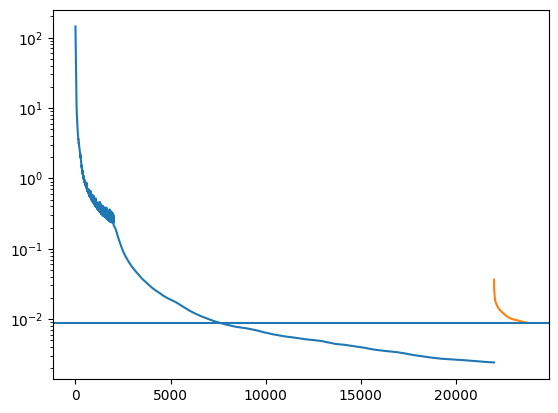

In [15]:
t = np.genfromtxt('checkpoints/losses.txt')
t2 = np.genfromtxt('checkpoints_lamrel_01/losses.txt')

plt.plot(t)

n = np.arange(len(t), len(t)+len(t2))
plt.plot(n, t2)
plt.yscale('log')
plt.axhline(8.9e-3)
# plt.xlim(22000, 22000+len(t2)+1000)

In [13]:
print(t2[:-10])

[0.03633378 0.0328436  0.03190475 0.03146513 0.03016478 0.0292779
 0.0284253  0.02785639 0.02702462 0.02635521 0.02585253 0.02561769
 0.02529393 0.02499671 0.02482344 0.02462958 0.02454458 0.02436921
 0.02415511 0.02392756 0.02368274 0.02339858 0.02328215 0.02307199
 0.02293622 0.02280534 0.02258692 0.02235359 0.02200826 0.02179618
 0.02158812 0.02140601 0.02117383 0.02096484 0.02078997 0.0206718
 0.02055778 0.02043254 0.02023474 0.02012299 0.01998966 0.01989684
 0.01981008 0.01973964 0.01959697 0.01955271 0.01943164 0.01936629
 0.01928408 0.01920867 0.01910169 0.0190414  0.01896049 0.01887557
 0.01883799 0.01871023 0.018663   0.01860634 0.01851144 0.01842406
 0.01837756 0.0183368  0.01828862 0.01820809 0.01811633 0.01805782
 0.0180229  0.01798118 0.01794306 0.01791396 0.01788895 0.01786223
 0.01782623 0.01774532 0.01771571 0.01768609 0.01766564 0.01762222
 0.01756731 0.01751802 0.01747949 0.01743928 0.01740724 0.01736361
 0.01733169 0.01730257 0.01727309 0.01724621 0.01721588 0.017197

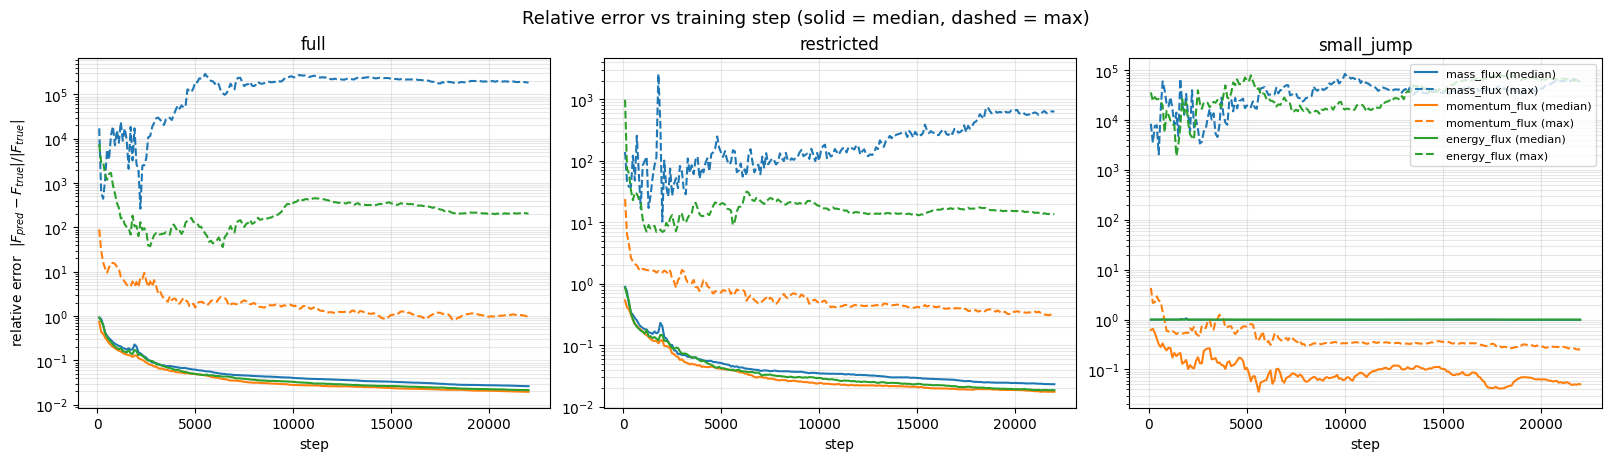

In [4]:
# Add metrics plot here
import csv
from pathlib import Path

import matplotlib.pyplot as plt

metrics_path = Path("checkpoints/metrics.csv")
with metrics_path.open() as f:
    rows = list(csv.DictReader(f))

steps = [int(r["step"]) for r in rows]

domains = ("full", "restricted", "small_jump")
channels = ("mass_flux", "momentum_flux", "energy_flux")
colors = {ch: c for ch, c in zip(channels, ("C0", "C1", "C2"))}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, constrained_layout=True)

for ax, domain in zip(axes, domains):
    for ch in channels:
        median = [float(r[f"median_rel_{domain}_{ch}"]) for r in rows]
        mx = [float(r[f"max_rel_{domain}_{ch}"]) for r in rows]
        ax.plot(steps, median, "-", color=colors[ch], label=f"{ch} (median)")
        ax.plot(steps, mx, "--", color=colors[ch], label=f"{ch} (max)")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(domain)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel(r"relative error  $|F_{pred} - F_{true}| / |F_{true}|$")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle("Relative error vs training step (solid = median, dashed = max)", fontsize=13)
plt.show()

In [5]:
from train import TRAIN_BOUNDS, F_true
from physics import GasState
import jax.numpy as jnp
import jax
names = ["t", "log10_rhoL", "log10_pL", "log10_rhoR", "log10_pR", "uRL"]

from checkpoint import load_latest
from train import F_pred, _build_model

ckpt_dir = Path.cwd() / "checkpoints"
F_net = load_latest(ckpt_dir, _build_model)

ckpt_dir = Path.cwd() / "checkpoints_lamrel_01"
F_net_rel = load_latest(ckpt_dir, _build_model)


gas_states = []
bound_pairs = []
name_pairs = []
fluxes = []
fluxes_pred = []
fluxes_rel_pred = []

N_grid = 512

# defaults
t_grid = jnp.full((N_grid**2,), 0.5)
log10_rhoL_grid = jnp.zeros((N_grid**2,))
log10_pL_grid = jnp.zeros((N_grid**2,))
log10_rhoR_grid = jnp.zeros((N_grid**2,))
log10_pR_grid = jnp.zeros((N_grid**2,))
uRL_grid = jnp.full((N_grid**2,), 0.0)
default_grids = [t_grid, log10_rhoL_grid, log10_pL_grid, log10_rhoR_grid, log10_pR_grid, uRL_grid]

for i in range(len(TRAIN_BOUNDS)):
    for j in range(len(TRAIN_BOUNDS)):
        if i==0 or j==0 or i==j or i>j:
            continue

        bound_pairs.append((TRAIN_BOUNDS[i], TRAIN_BOUNDS[j]))
        
        lin_i = jnp.linspace(TRAIN_BOUNDS[i][0], TRAIN_BOUNDS[i][1], N_grid)
        lin_j = jnp.linspace(TRAIN_BOUNDS[j][0], TRAIN_BOUNDS[j][1], N_grid)
        X, Y = jnp.meshgrid(lin_i, lin_j, indexing="ij")

        grid_array = []
        for k in range(len(TRAIN_BOUNDS)):
            if k==i:
                grid_array.append(X.flatten())
            elif k==j:
                grid_array.append(Y.flatten())
            else:
                grid_array.append(default_grids[k])

        grid = jnp.stack(grid_array, axis=-1)
        gas_states.append(GasState.from_array(grid))

        name_pairs.append((names[i], names[j]))
        # print(name_pairs[-1])

        flux_ = jax.vmap(F_true)(grid)
        fluxes.append(jnp.reshape(flux_, (N_grid, N_grid, 3)))

        flux_pred_ = jax.vmap(lambda r: F_pred(F_net, r))(grid)
        fluxes_pred.append(jnp.reshape(flux_pred_, (N_grid, N_grid, 3)))

        flux_pred_rel_ = jax.vmap(lambda r: F_pred(F_net_rel, r))(grid)
        fluxes_rel_pred.append(jnp.reshape(flux_pred_rel_, (N_grid, N_grid, 3)))
    


loading latest checkpoint from /scratch/ab13780/riemaNN/innt/riemann/checkpoints/F_net_022000.msgpack
loading latest checkpoint from /scratch/ab13780/riemaNN/innt/riemann/checkpoints_lamrel_01/F_net_004000.msgpack


min flux [-1.00000000e+02  1.00000000e-02 -1.82670119e+03]
max flux [  40.84787123  101.         1826.70118567]


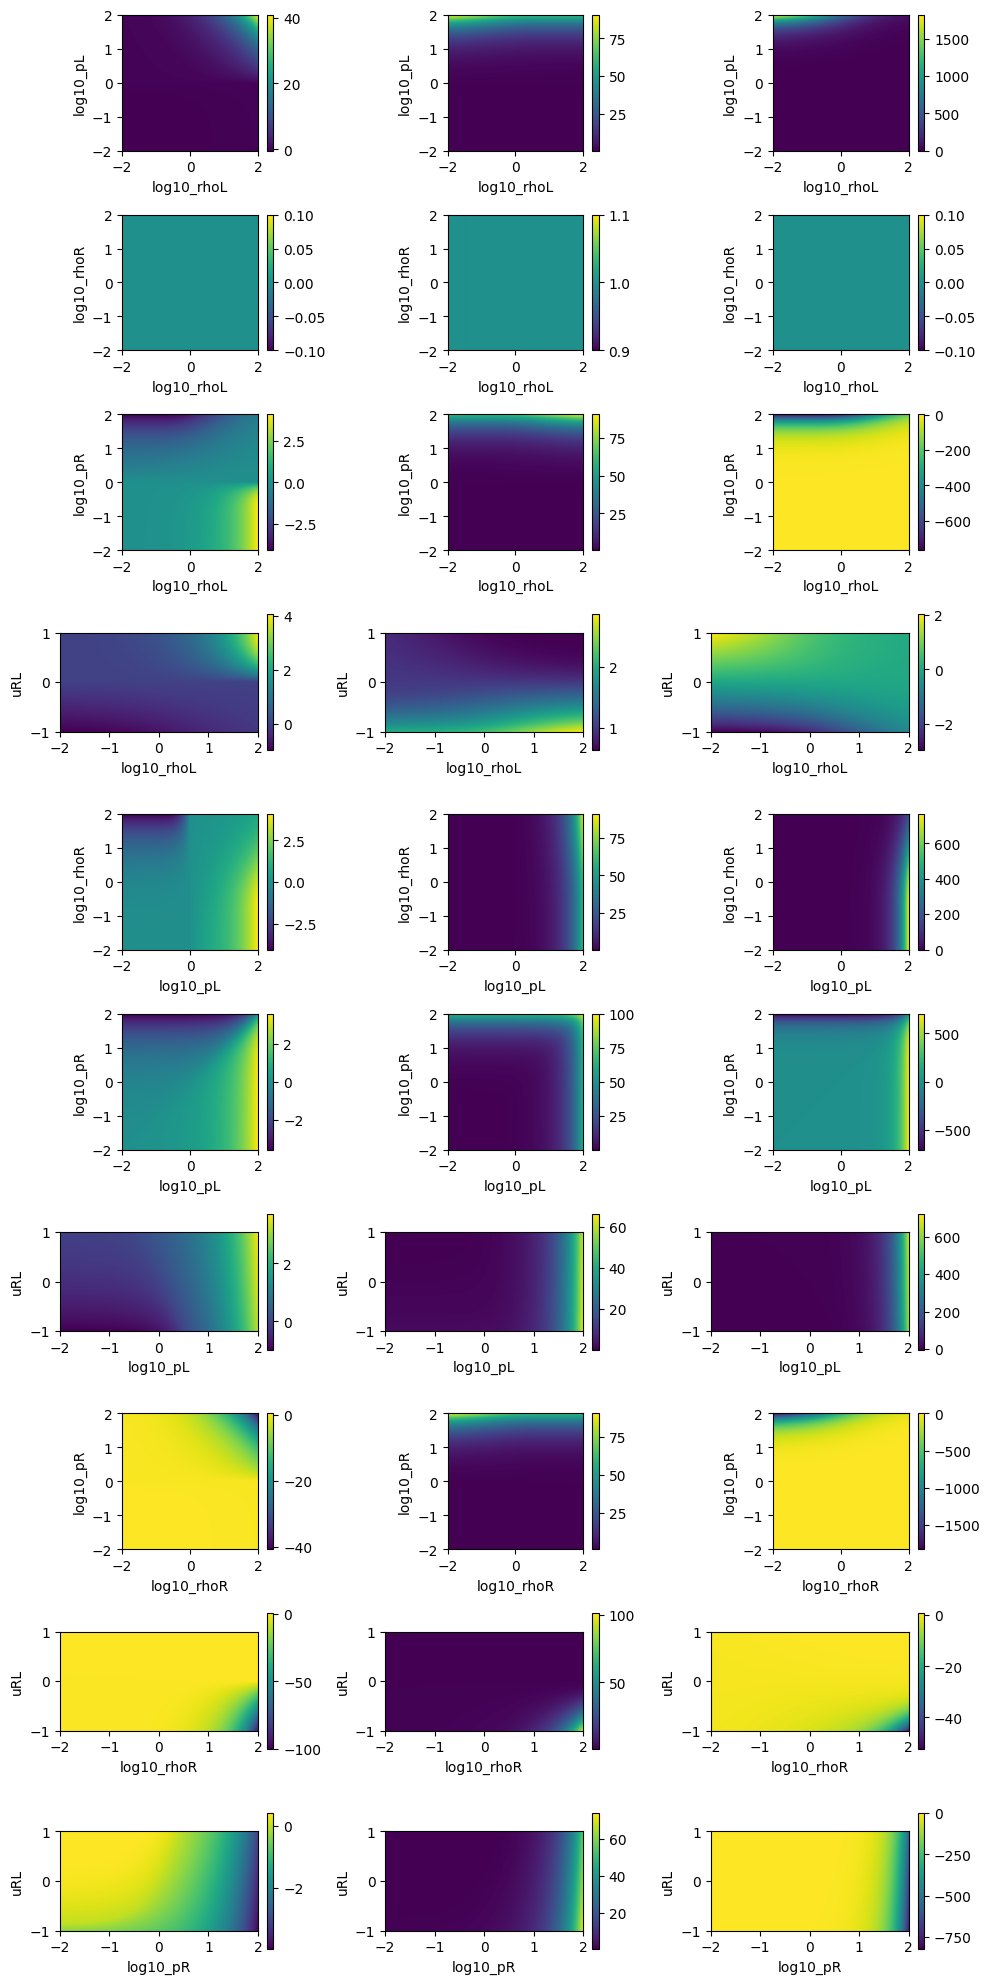

In [17]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))

min_flux = jnp.full(3, jnp.inf)
max_flux = jnp.full(3, -jnp.inf)

for i, axr in enumerate(axs):
    min_flux = jnp.minimum(min_flux, fluxes[i].min(axis=(0,1)))
    max_flux = jnp.maximum(max_flux, fluxes[i].max(axis=(0,1)))
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        im = ax.imshow(fluxes[i][...,j].T, origin="lower", extent=extent)
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print('min flux', min_flux)
print('max flux', max_flux)

fig.tight_layout()
plt.show()


In [6]:
gs = GasState(log10_rhoL=0, log10_pL=0, log10_rhoR=2, log10_pR=2, uRL=0)
x = jnp.concatenate([jnp.array([0.1]), gs.as_array()])
print(F_true(x))

[-40.84787123  63.28125    -76.58975856]


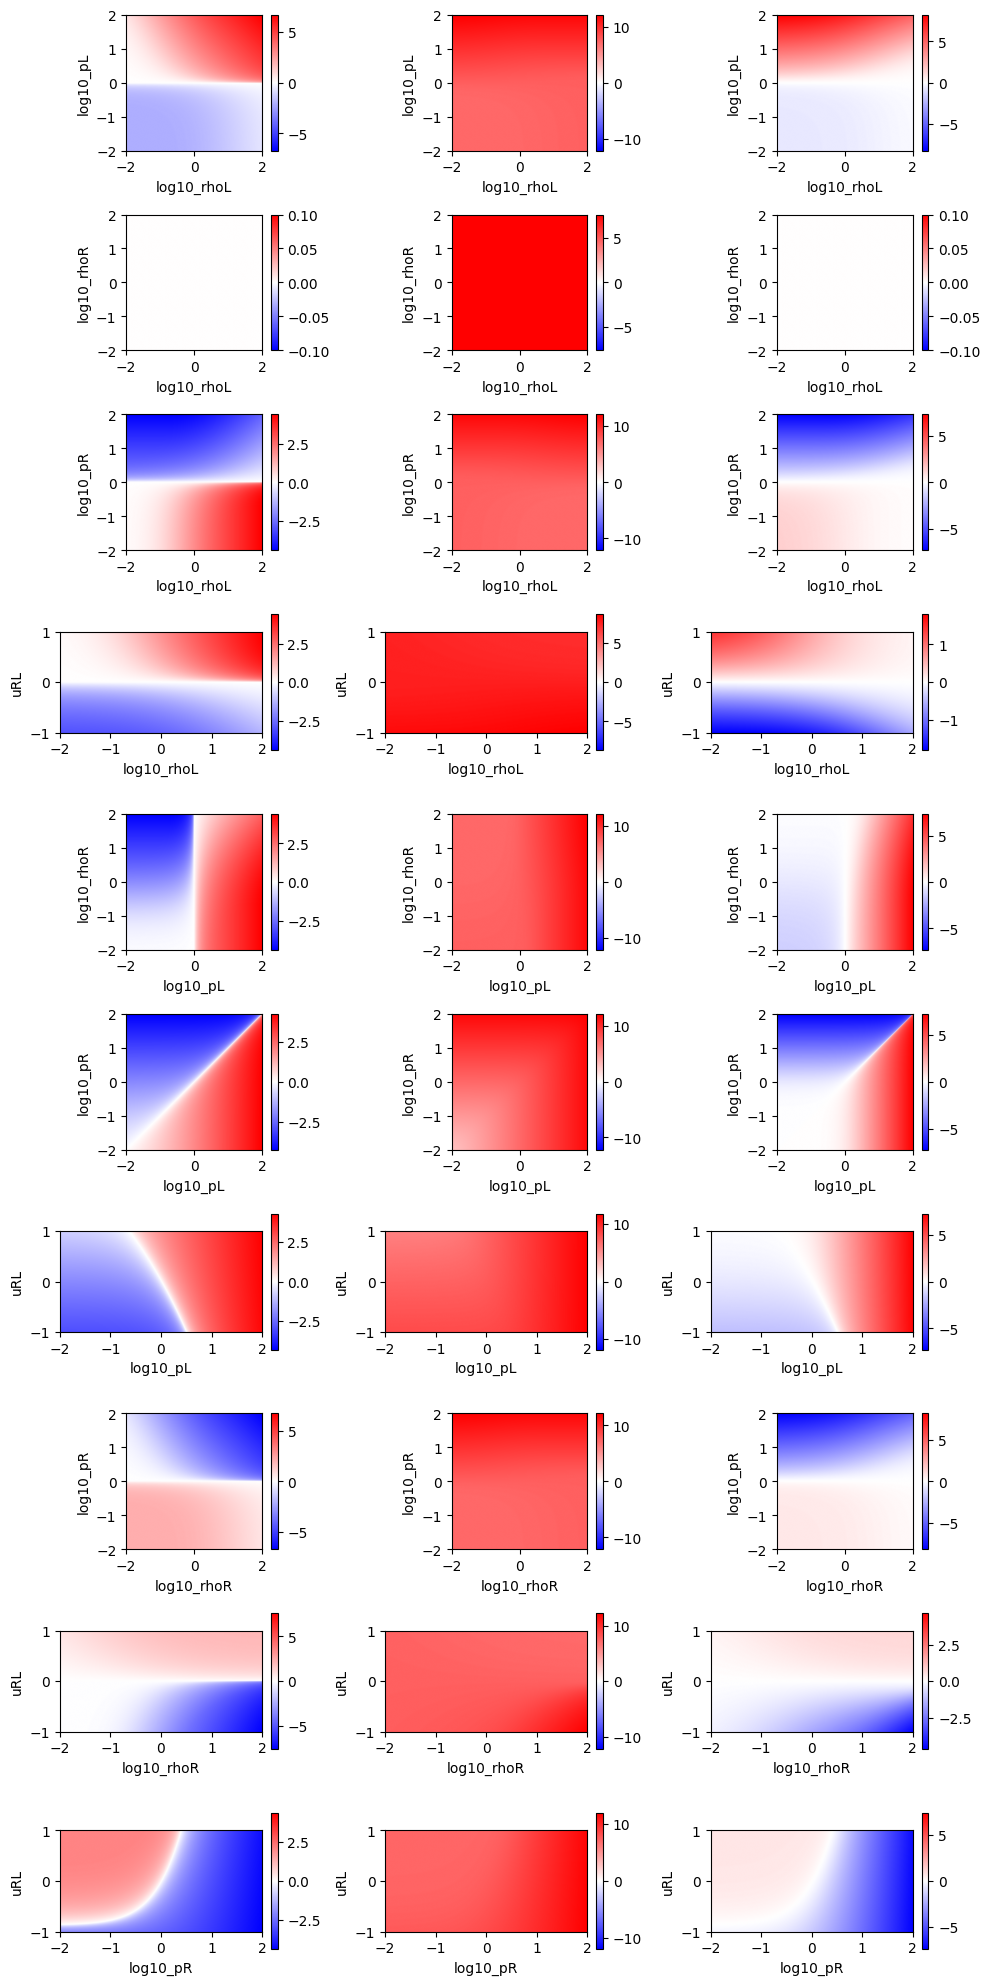

In [7]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE
MY_FLUX_SCALE = jnp.array([1e-1, 1e-3, 1e0])

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / MY_FLUX_SCALE[j])
        vmax = jnp.abs(flux_scaled).max()
        im = ax.imshow(
            flux_scaled.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


In [51]:
print(FLUX_SCALE)

[1.e-05 1.e-03 1.e-05]


[[-3.52979272e-01  6.52965061e-01 -6.99518329e-01]
 [-3.52951617e-01  6.52979818e-01 -6.99480829e-01]
 [-3.52923704e-01  6.52994716e-01 -6.99442975e-01]
 ...
 [ 3.49684856e+00  6.41064399e+01  6.80362394e+02]
 [ 3.51328332e+00  6.46987298e+01  6.89874052e+02]
 [ 3.52979272e+00  6.52965061e+01  6.99518329e+02]]


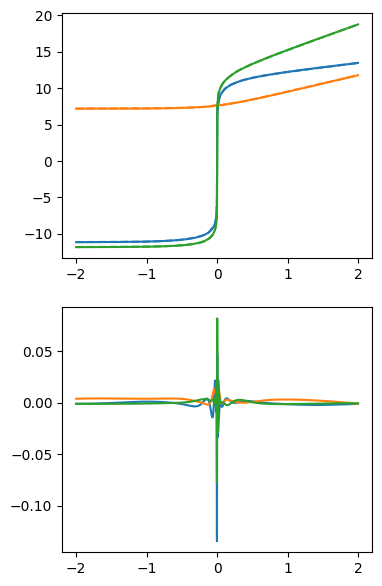

In [35]:
N = 1000
gs = GasState(log10_rhoL=jnp.zeros(N), 
              log10_pL=jnp.linspace(-2, 2, N), 
              log10_rhoR=jnp.zeros(N), 
              log10_pR=jnp.zeros(N), 
              uRL=jnp.zeros(N))

# Correct shape construction: stack each data point as a row
x = jnp.concatenate(
    [jnp.full((N, 1), 0.1), gs.as_array().reshape(N, -1)],
    axis=1
)

flux = jax.vmap(F_true)(x)
flux_pred = F_net(x)

# MY_FLUX_SCALE = jnp.array([1e-1, 1e-3, 1e0])
flux_scaled = jnp.arcsinh(flux / FLUX_SCALE)


print(flux)

fig, axs = plt.subplots(2, 1, figsize=(4, 7))

l = axs[0].plot(gs.log10_pL, flux_scaled[..., 0])
axs[0].plot(gs.log10_pL, flux_pred[..., 0], '--', color=l[0].get_color())
l = axs[0].plot(gs.log10_pL, flux_scaled[..., 1])
axs[0].plot(gs.log10_pL, flux_pred[..., 1], '--', color=l[0].get_color())
l = axs[0].plot(gs.log10_pL, flux_scaled[..., 2])
axs[0].plot(gs.log10_pL, flux_pred[..., 2], '--', color=l[0].get_color())


ax = axs[1]
err = (flux_pred - flux_scaled) / (flux_scaled + 1e-4)
ax.plot(gs.log10_pL, err[..., 0])
ax.plot(gs.log10_pL, err[..., 1])
ax.plot(gs.log10_pL, err[..., 2])
# ax.set_ylim(-10, 10)

plt.show()


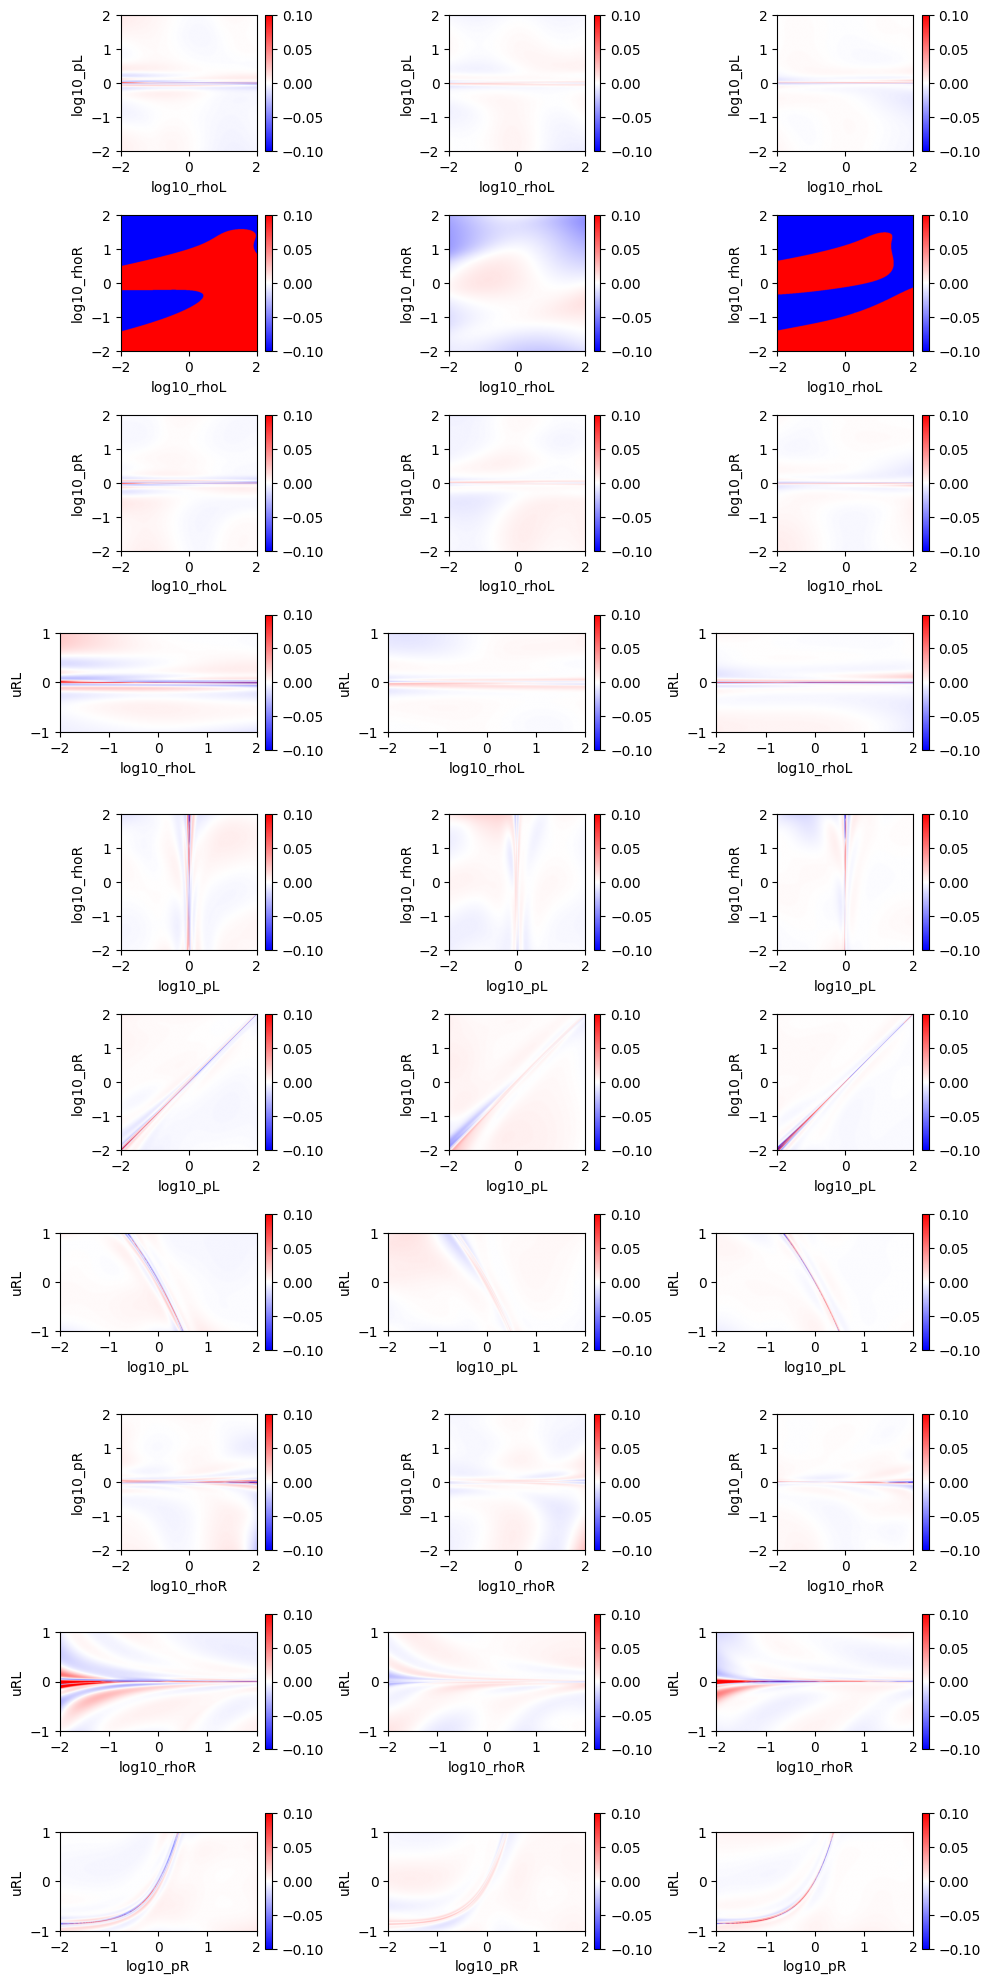

In [37]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / FLUX_SCALE[j])
        flux_scaled_pred = jnp.arcsinh(fluxes_pred[i][...,j] / FLUX_SCALE[j])
        err = (flux_scaled_pred - flux_scaled) / (jnp.abs(flux_scaled) + 1e-4)

        # vmax = jnp.abs(err).max()
        vmax = 0.1
        im = ax.imshow(
            err.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


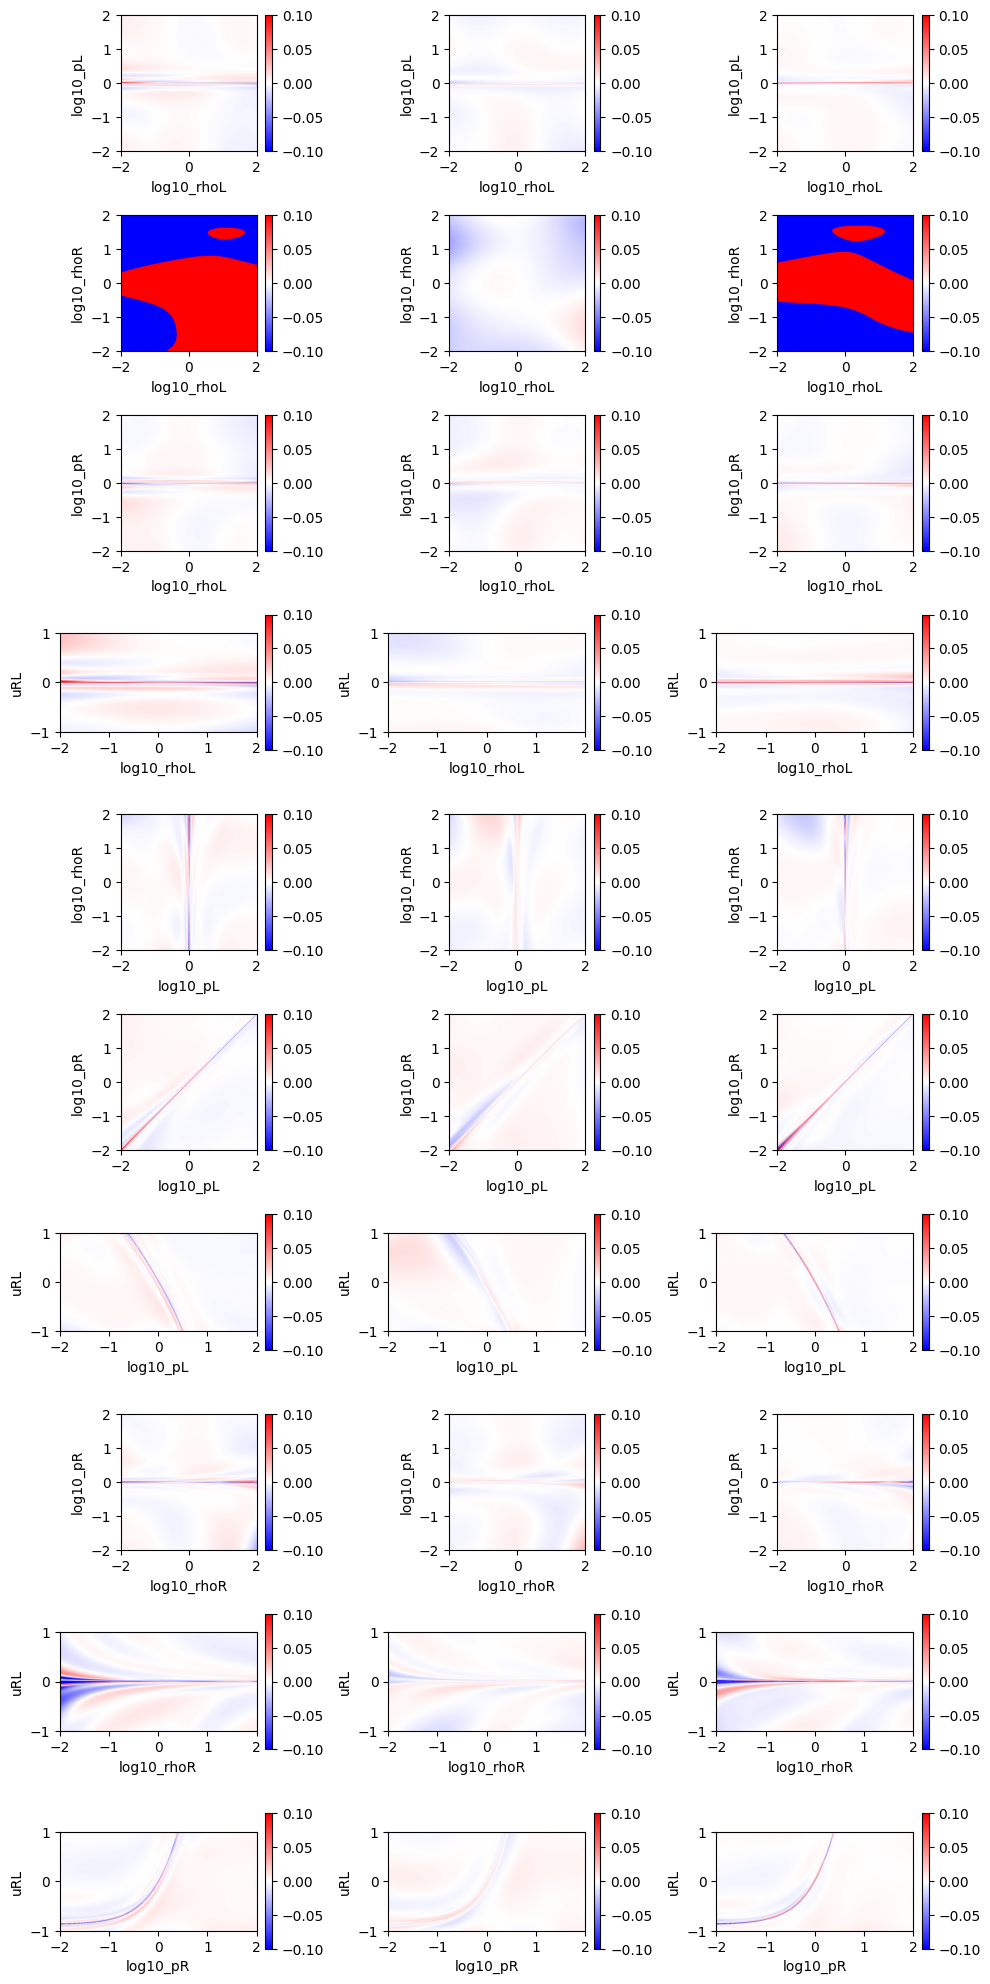

In [39]:
fig, axs = plt.subplots(10, 3, figsize=(10, 20))
from train import FLUX_SCALE

for i, axr in enumerate(axs):
    for j, ax in enumerate(axr):
        extent = [bound_pairs[i][0][0], bound_pairs[i][0][1], bound_pairs[i][1][0], bound_pairs[i][1][1]]
        
        flux_scaled = jnp.arcsinh(fluxes[i][...,j] / FLUX_SCALE[j])
        flux_scaled_pred = jnp.arcsinh(fluxes_rel_pred[i][...,j] / FLUX_SCALE[j])
        err = (flux_scaled_pred - flux_scaled) / (jnp.abs(flux_scaled) + 1e-4)

        # vmax = jnp.abs(err).max()
        vmax = 0.1
        im = ax.imshow(
            err.T,
            origin="lower",
            extent=extent,
            cmap="bwr",
            vmin=-vmax,
            vmax=+vmax
        )
        # ax.set_title(name_pairs[i])
        ax.set_xlabel(name_pairs[i][0])
        ax.set_ylabel(name_pairs[i][1])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()
